In [1]:
import optuna

study = optuna.load_study(
    study_name='rollout_coupled',
    storage='sqlite:///../optuna_rollout.db'
)


# Parameter importance
optuna.visualization.plot_param_importances(study).show()

# Optimization history
optuna.visualization.plot_optimization_history(study).show()

# Parallel coordinate plot (good for seeing interactions)
optuna.visualization.plot_parallel_coordinate(study).show()

# Slice plot (each param vs objective)
optuna.visualization.plot_slice(study).show()


In [22]:
import sys
sys.path.append('..')

import json, torch
from torch import nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from model_stuff import Predictor
from Rollout import train_rollout
from CoupledModel import CoupledModel

best = study.best_params
print(json.dumps(best, indent=2))




{
  "lag": 200,
  "train_horizon": 20,
  "hidden_size_AMOC": 64,
  "num_layers_AMOC": 2,
  "dropout_AMOC": 0.4864425324166589,
  "lr_AMOC": 0.0006220061255408285,
  "hidden_size_SFWF": 32,
  "num_layers_SFWF": 1,
  "dropout_SFWF": 0.10034215389312154,
  "lr_SFWF": 0.004214326514377264,
  "hidden_size_PD_200m": 128,
  "num_layers_PD_200m": 1,
  "dropout_PD_200m": 0.43185429320276136,
  "lr_PD_200m": 0.00045173713719212286
}


In [23]:
model_vars = ['AMOC', 'SFWF', 'PD_200m']
features   = {name: [v for v in model_vars if v != name] for name in model_vars}
n_features = len(model_vars) - 1

train_cut_1 = 5000
train_cut_2 = 11000
device      = 'cpu'

X_df     = pd.read_csv('../../data/CESMDataset_Try.csv')
train_idx = list(range(train_cut_1)) + list(range(train_cut_2, len(X_df)))

scalers  = {}
X_scaled = X_df[model_vars].copy().astype(float)
for var in model_vars:
    sc = StandardScaler().fit(X_df[var].values[train_idx].reshape(-1, 1))
    X_scaled[var] = sc.transform(X_df[var].values.reshape(-1, 1))
    scalers[var] = sc

lag           = best['lag']
train_horizon = best['train_horizon']

models = {
    name: Predictor(
        n_features=n_features,
        hidden_size=best[f'hidden_size_{name}'],
        num_layers=1,
        dropout=best[f'dropout_{name}'],
    ).to(device)
    for name in model_vars
}

lrs = {name: best[f'lr_{name}'] for name in model_vars}


In [24]:
transition_prob = 0.7
threshold_scaled = 7.0 / scalers['AMOC'].scale_[0]
search_ahead = 100

train_losses = train_rollout(
    X_scaled, 
    train_cut_1, 
    train_cut_2, 
    transition_prob, 
    threshold_scaled, 
    search_ahead,
    models, 
    features,
    train_steps=500,
    lag=lag,
    train_horizon=40,
    loss_fn=nn.L1Loss(),
    lrs=lrs,
)


In [25]:
trained_models = {}

for name in model_vars:
    feature_cols = features[name]
    x_sc = StandardScaler().fit(X_df[feature_cols].values[train_idx])
    
    trained_models[name] = {
        'model':    models[name],
        'x_scaler': x_sc,
        'y_scaler': scalers[name],
    }

coupled = CoupledModel.from_trained(trained_models)


In [28]:
horizon = 1
rho = 0.8
k = 0.3

start_idx = 6500
models = ['AMOC', 'SFWF', 'PD_200m']
features = {
    'AMOC': ['SFWF', 'PD_200m'],
    'SFWF': ['AMOC', 'PD_200m'],
    'PD_200m': ['SFWF', 'AMOC'],
}
steps = 5000
threshold = 13

predictions = coupled.predict(device, X_df, start_idx, lag, horizon, models, features, steps, threshold, rho, k)

/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


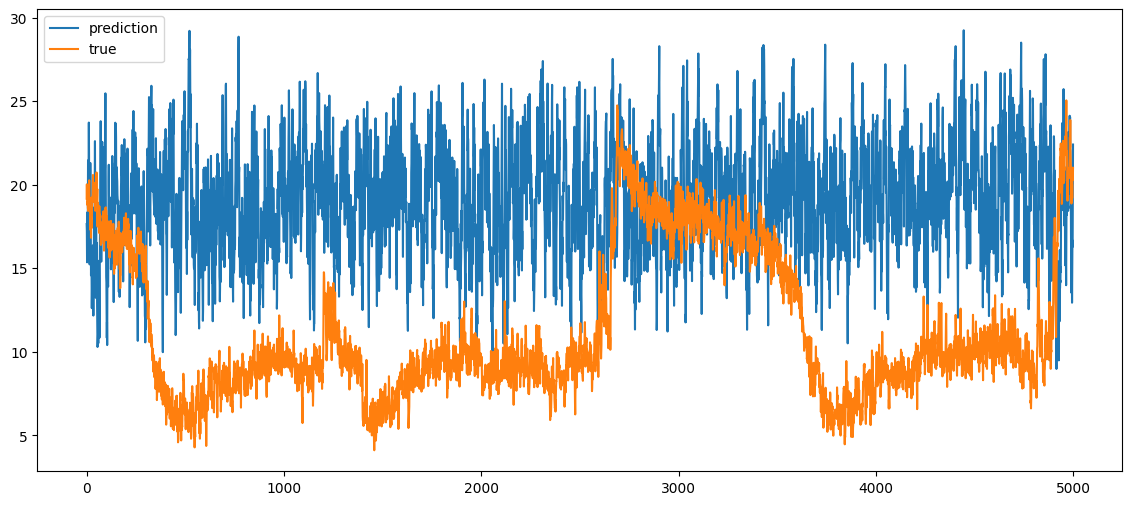

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, predictions['AMOC'], label = 'prediction')
plt.plot(x, X_df['AMOC'][start_idx:start_idx+5000], label = 'true')
plt.legend()

In [48]:
def _sample_transitions(X, threshold, search_ahead, lag):
    transition_starts = []
    normal_starts     = []
    for w in range(lag, len(X) - lag - search_ahead):
        future = X['AMOC'].iloc[w + lag : w + lag + search_ahead]
        if future.max() - future.min() > threshold:
            transition_starts.append(w)
        else:
            normal_starts.append(w)
    return transition_starts, normal_starts

transition_starts, normal_starts = _sample_transitions(X_df[5000:11000], 14, 500, 100) 

In [52]:
len(transition_starts)

1389

In [53]:
transition_starts[1000:]

[3829,
 3830,
 3831,
 3832,
 3833,
 3834,
 3835,
 3836,
 3837,
 3838,
 3839,
 3840,
 3841,
 3842,
 3843,
 3844,
 3845,
 3846,
 3847,
 3848,
 3849,
 3850,
 3851,
 3852,
 3853,
 3854,
 3855,
 3856,
 3857,
 3858,
 3859,
 3860,
 3861,
 3862,
 3863,
 3864,
 3865,
 3866,
 3867,
 3868,
 3869,
 3870,
 3871,
 3872,
 3873,
 3874,
 3875,
 3876,
 3877,
 3878,
 3879,
 3880,
 3881,
 3882,
 3883,
 3884,
 3885,
 3886,
 3887,
 3888,
 3889,
 3890,
 3891,
 3892,
 3893,
 3894,
 3895,
 3896,
 3897,
 3898,
 3899,
 3900,
 3901,
 3902,
 3903,
 3904,
 3905,
 3906,
 3907,
 3908,
 3909,
 3910,
 3911,
 3912,
 3913,
 3914,
 3915,
 3916,
 3917,
 3918,
 3919,
 3920,
 3921,
 3922,
 3923,
 3924,
 3925,
 3926,
 3927,
 3928,
 3929,
 3930,
 3931,
 3932,
 3933,
 3934,
 3935,
 3936,
 3937,
 3938,
 3939,
 3940,
 3941,
 3942,
 3943,
 3944,
 3945,
 3946,
 3947,
 3948,
 3949,
 3950,
 3951,
 3952,
 3953,
 3954,
 3955,
 3956,
 3957,
 3958,
 3959,
 3960,
 3961,
 3962,
 3963,
 3964,
 3965,
 3966,
 3967,
 3968,
 3969,
 3970,
 3971,

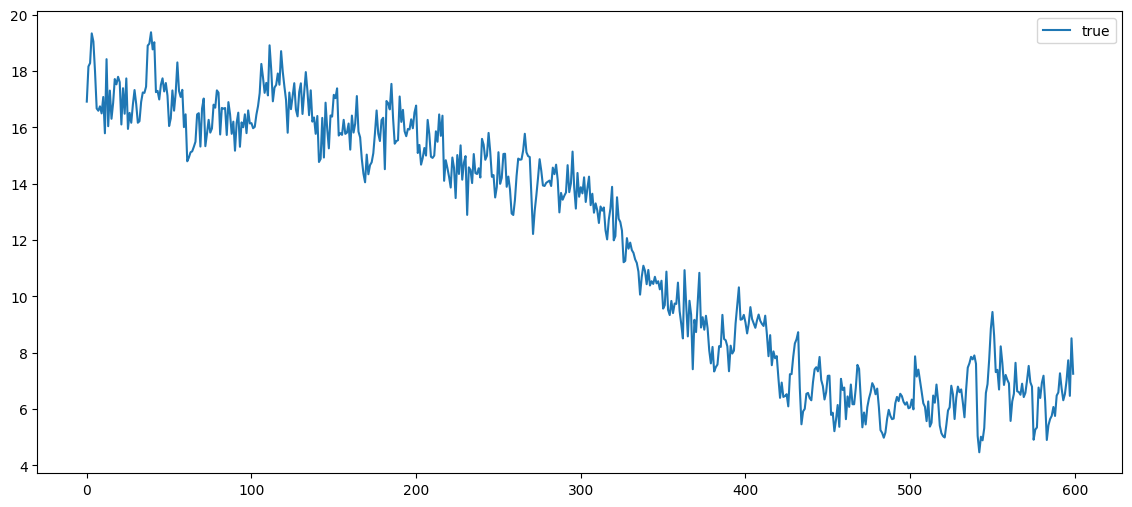

In [54]:
plt.figure(figsize=(14,6))

x = np.arange(600)

plt.plot(x, X_df['AMOC'][9800:10400], label = 'true')
plt.legend()